<a href="https://colab.research.google.com/github/OmarMuhammed77/Diabetes_Risk_Prediction/blob/main/Diabetes_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
df=pd.read_csv("/content/diabetes_risk.csv")

In [93]:
df.shape

(15000, 19)

In [94]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [95]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,patient_id,int64,"[15000, 1, 2, 3, 4, 5, 6, 7, 14984, 14983]",15000,0,0.000000,0
1,age,int64,"[47, 46, 48, 45, 44, 50, 43, 49, 42, 52]",58,0,0.000000,0
2,gender,object,"[Male, Female, Other]",3,0,0.000000,0
3,city,object,"[Mumbai, Delhi, Bengaluru, Hyderabad, Ahmedaba...",18,0,0.000000,0
4,bmi,float64,"[21.6, 20.8, 21.3, 22.1, 22.2, 24.0, 22.7, 21....",239,0,0.000000,0
5,family_history_diabetes,object,"[No, Yes]",2,0,0.000000,0
6,physical_activity_level,object,"[Active, Sedentary, Moderate]",3,0,0.000000,0
7,diet_type,object,"[Non-Vegetarian, Vegetarian, Pescatarian, Vegan]",4,0,0.000000,0
8,smoking_status,object,"[Never, Current, Former]",3,472,3.146667,0
9,alcohol_consumption,object,"[Never, Occasional, Regular]",3,3788,25.253333,0


In [96]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
patient_id,15000.000000,7500.500000,4330.271354,1.000000,3750.750000,7500.500000,11250.250000,15000.000000
age,15000.000000,44.333667,10.383753,18.000000,38.000000,45.000000,52.000000,80.000000
bmi,15000.000000,23.062260,4.046391,15.000000,20.100000,22.700000,25.600000,40.800000
hours_sleep_per_night,15000.000000,7.309860,1.109372,3.000000,6.700000,7.000000,8.000000,12.000000
stress_level,15000.000000,5.941200,2.148406,1.000000,4.000000,6.000000,7.000000,10.000000
fasting_blood_sugar,15000.000000,168.789933,38.365822,72.000000,145.000000,165.000000,189.000000,400.000000
hba1c_level,15000.000000,6.878387,0.843276,4.800000,6.300000,6.800000,7.300000,13.400000
blood_pressure_systolic,15000.000000,139.496200,12.660785,80.000000,130.000000,140.000000,150.000000,200.000000
blood_pressure_diastolic,15000.000000,86.256933,8.386529,50.000000,80.000000,88.000000,90.000000,120.000000
waist_circumference_cm,15000.000000,100.207933,10.760331,73.200000,92.500000,99.300000,106.900000,148.200000


In [97]:
checkOutliers=list(df.select_dtypes(include='number'))
checkOutliers.pop(0)
print(checkOutliers)


['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']


/tmp/ipykernel_2703/3581358765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_2703/3581358765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_2703/3581358765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
/tmp/ipykernel_2703/3581358765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

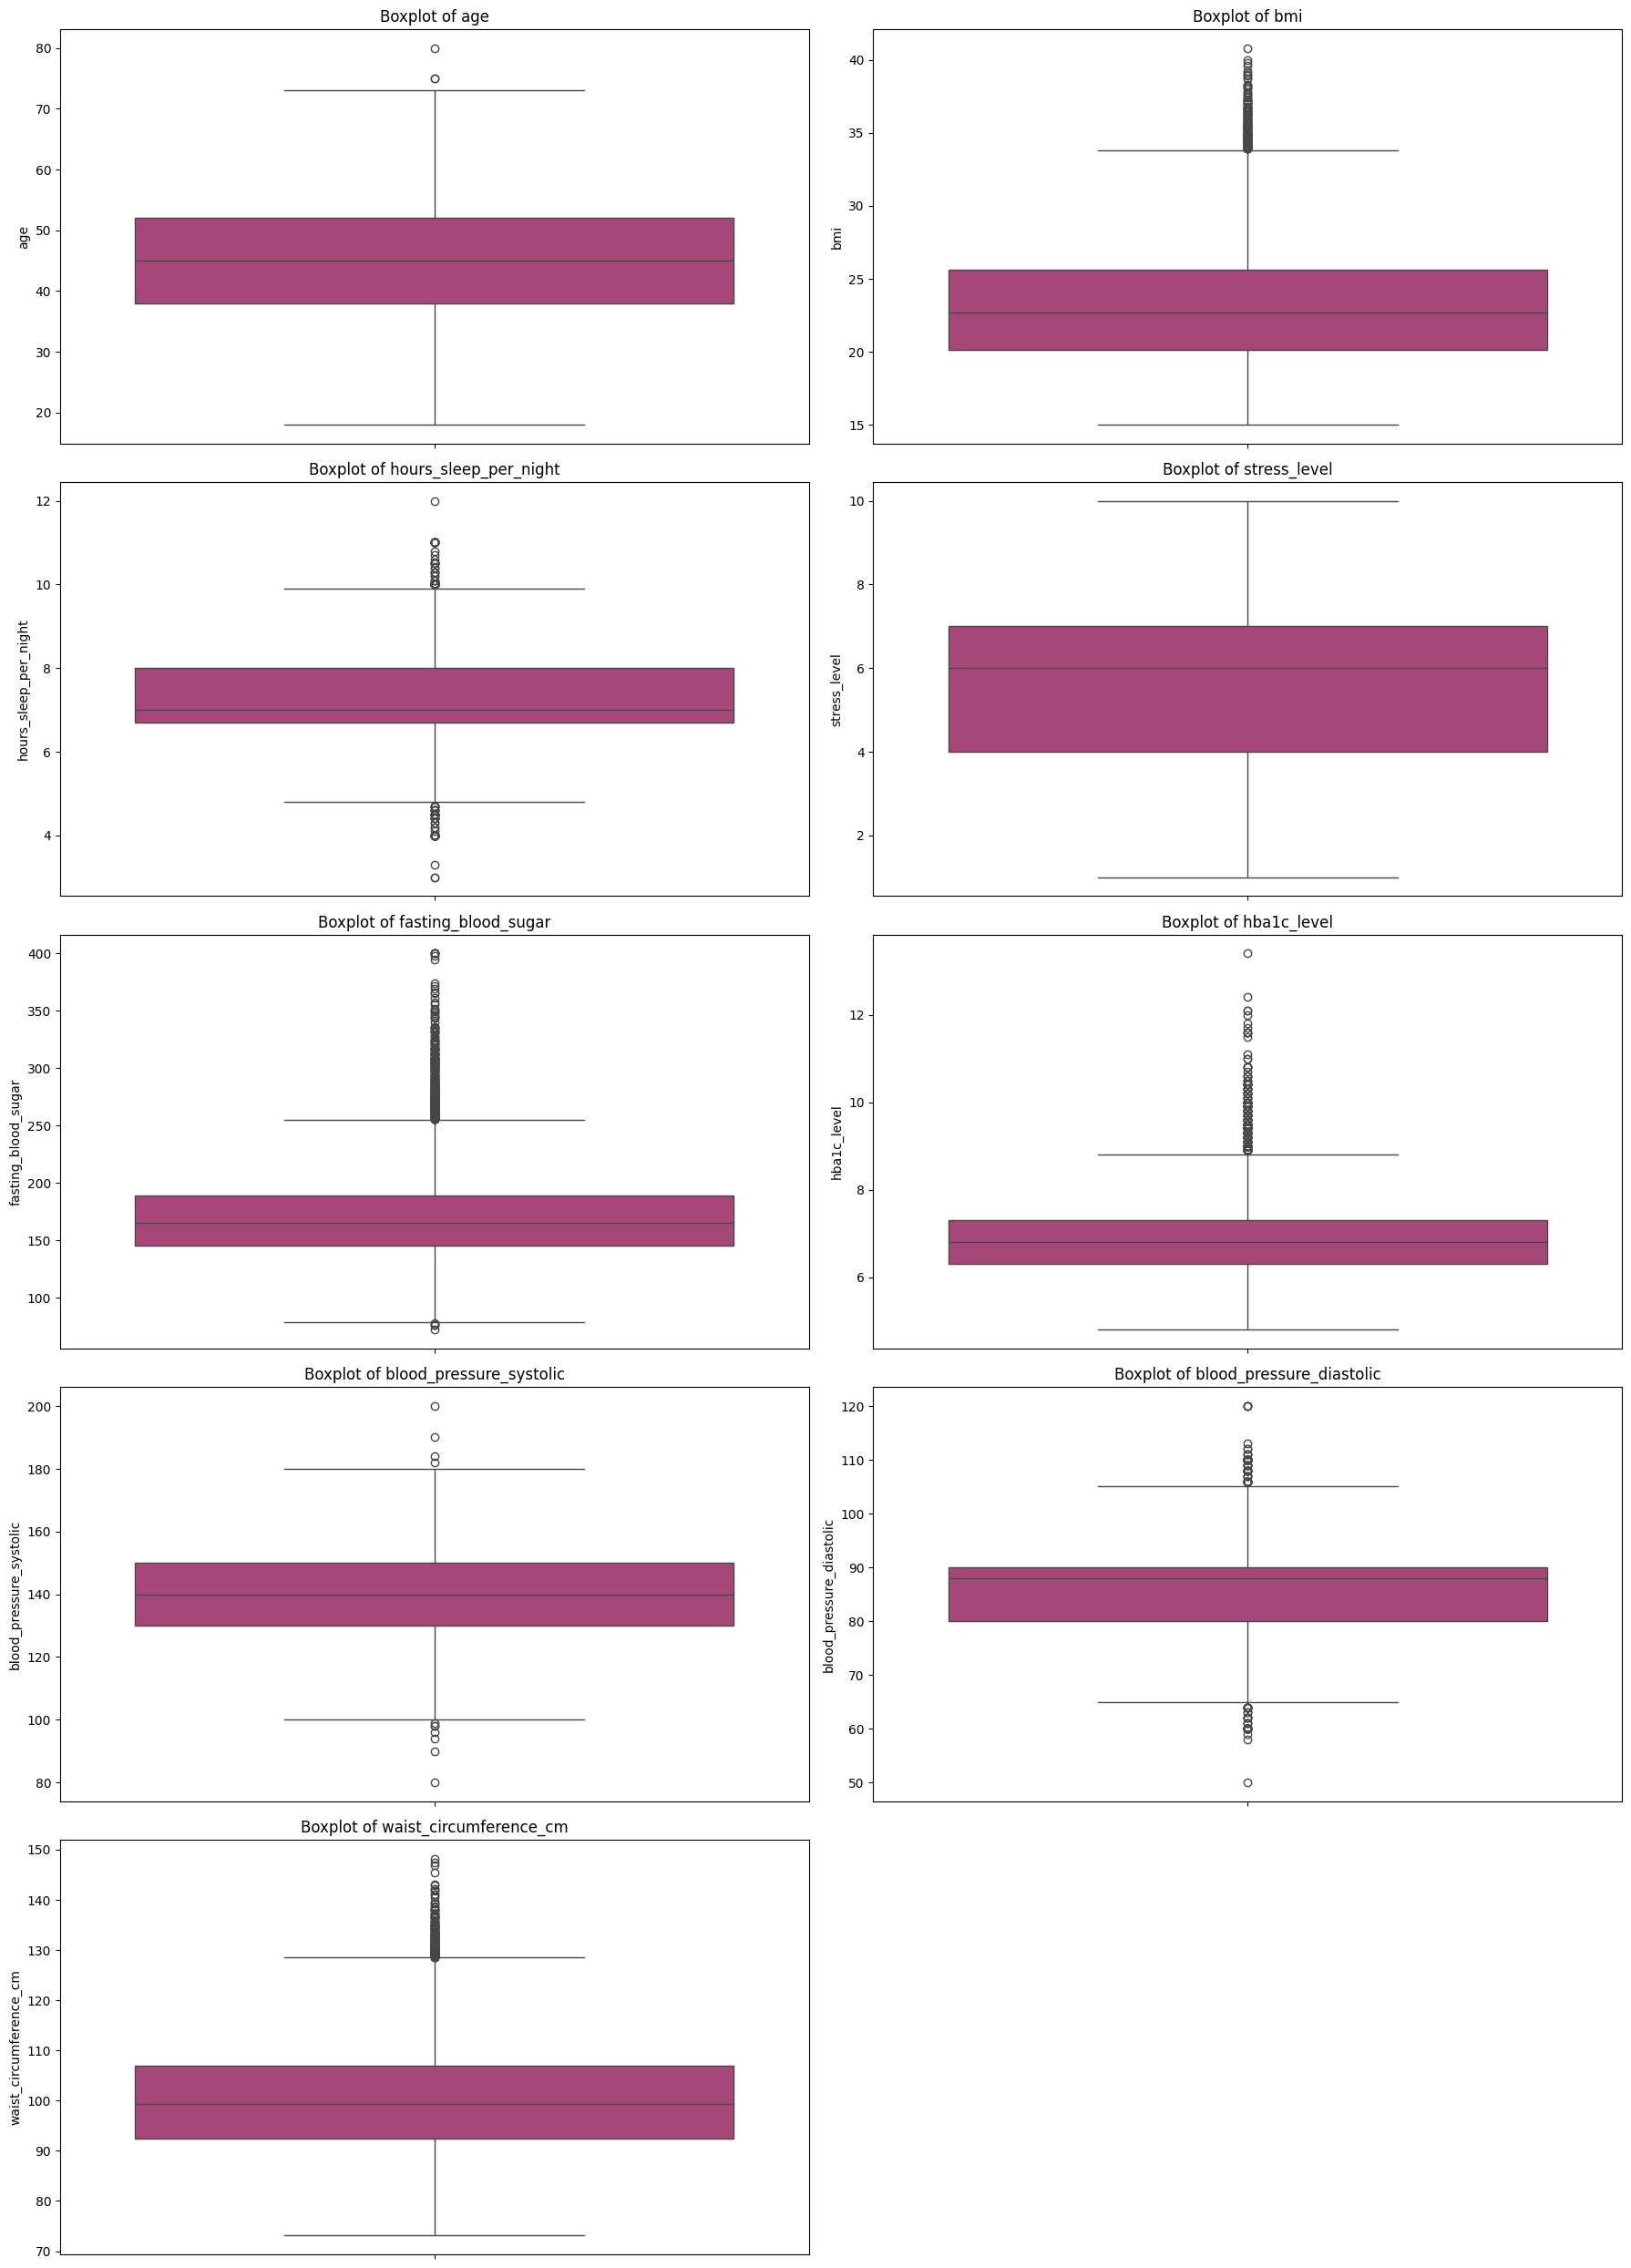

In [98]:

n_cols = 2
n_rows = int(np.ceil(len(checkOutliers) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data=df, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [99]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,472
alcohol_consumption,3788


In [100]:
x=df.drop(['patient_id','diabetes_risk'],axis=1)
y=df['diabetes_risk']

In [101]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=32)

In [102]:
numeric_features = x_train.select_dtypes(include=np.number).columns
categorical_features = x_train.select_dtypes(include='object').columns

print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']
Categorical: ['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


In [103]:
#Handling NULLS on numeric columns

num_imputer = SimpleImputer(strategy='median')

x_train[numeric_features] = num_imputer.fit_transform(x_train[numeric_features])
x_test[numeric_features] = num_imputer.transform(x_test[numeric_features])

In [104]:
#Handling NULLS categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

x_train[categorical_features] = cat_imputer.fit_transform(x_train[categorical_features])
x_test[categorical_features] = cat_imputer.transform(x_test[categorical_features])

In [105]:
data_info(x_train.select_dtypes(include='object'))

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,gender,object,"[Male, Female, Other]",3,0,0.0,6900
1,city,object,"[Mumbai, Delhi, Bengaluru, Hyderabad, Ahmedaba...",18,0,0.0,6900
2,family_history_diabetes,object,"[No, Yes]",2,0,0.0,6900
3,physical_activity_level,object,"[Active, Sedentary, Moderate]",3,0,0.0,6900
4,diet_type,object,"[Non-Vegetarian, Vegetarian, Pescatarian, Vegan]",4,0,0.0,6900
5,smoking_status,object,"[Never, Current, Former]",3,0,0.0,6900
6,alcohol_consumption,object,"[Never, Occasional, Regular]",3,0,0.0,6900
7,income_bracket,object,"[Middle, High, Low]",3,0,0.0,6900


In [106]:
# converting ordinal categories into numerical

activity_mapping = {
    'Sedentary': 0,
    'Moderate': 1,
    'Active': 2
}

alcohol_mapping = {
    'Never': 0,
    'Occasional': 1,
    'Regular': 2
}

income_mapping = {
    'Low': 0,
    'Middle': 1,
    'High': 2
}

x_train['physical_activity_level'] = x_train['physical_activity_level'].map(activity_mapping)
x_test['physical_activity_level'] = x_test['physical_activity_level'].map(activity_mapping)

x_train['alcohol_consumption'] = x_train['alcohol_consumption'].map(alcohol_mapping)
x_test['alcohol_consumption'] = x_test['alcohol_consumption'].map(alcohol_mapping)

x_train['income_bracket'] = x_train['income_bracket'].map(income_mapping)
x_test['income_bracket'] = x_test['income_bracket'].map(income_mapping)

In [107]:
#binary maping for family_history_diabetes
binary_mapping = {
    'No': 0,
    'Yes': 1
}

x_train['family_history_diabetes'] = x_train['family_history_diabetes'].map(binary_mapping)
x_test['family_history_diabetes'] = x_test['family_history_diabetes'].map(binary_mapping)

In [108]:
nominal_cols= list(x_train.select_dtypes(include='object'))

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_encoded = encoder.fit_transform(x_train[nominal_cols])
x_test_encoded = encoder.transform(x_test[nominal_cols])

In [109]:
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_train.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_test.index
)

In [110]:
data_info(x_train_encoded)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,gender_Female,float64,"[0.0, 1.0]",2,0,0.0,11578
1,gender_Male,float64,"[1.0, 0.0]",2,0,0.0,11578
2,gender_Other,float64,"[0.0, 1.0]",2,0,0.0,11578
3,city_Ahmedabad,float64,"[0.0, 1.0]",2,0,0.0,11578
4,city_Bengaluru,float64,"[0.0, 1.0]",2,0,0.0,11578
5,city_Bhopal,float64,"[0.0, 1.0]",2,0,0.0,11578
6,city_Chennai,float64,"[0.0, 1.0]",2,0,0.0,11578
7,city_Delhi,float64,"[0.0, 1.0]",2,0,0.0,11578
8,city_Hyderabad,float64,"[0.0, 1.0]",2,0,0.0,11578
9,city_Indore,float64,"[0.0, 1.0]",2,0,0.0,11578


In [111]:
x_train = x_train.drop(columns=nominal_cols,axis=1)
x_test = x_test.drop(columns=nominal_cols,axis=1)

x_train = pd.concat([x_train, x_train_encoded], axis=1)
x_test = pd.concat([x_test, x_test_encoded], axis=1)


In [112]:
data_info(x_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,float64,"[47.0, 46.0, 48.0, 50.0, 45.0, 44.0, 43.0, 49....",58,0,0.0,0
1,bmi,float64,"[21.6, 21.3, 23.5, 22.8, 22.7, 22.2, 24.0, 23....",235,0,0.0,0
2,family_history_diabetes,int64,"[0, 1]",2,0,0.0,0
3,physical_activity_level,int64,"[2, 0, 1]",3,0,0.0,0
4,alcohol_consumption,int64,"[0, 1, 2]",3,0,0.0,0
5,hours_sleep_per_night,float64,"[7.0, 8.0, 6.0, 9.0, 7.5, 6.5, 5.0, 8.5, 10.0,...",72,0,0.0,0
6,stress_level,float64,"[6.0, 7.0, 5.0, 4.0, 8.0, 9.0, 3.0, 10.0, 2.0,...",10,0,0.0,0
7,fasting_blood_sugar,float64,"[159.0, 158.0, 164.0, 165.0, 162.0, 157.0, 161...",268,0,0.0,0
8,hba1c_level,float64,"[6.5, 6.7, 6.8, 6.6, 6.9, 7.0, 6.4, 7.1, 7.2, ...",69,0,0.0,0
9,blood_pressure_systolic,float64,"[140.0, 130.0, 150.0, 120.0, 160.0, 136.0, 144...",85,0,0.0,0
